# FlyWire optic lobes co-clustering 

In this example, we will run a large co-cluster over both optic lobes of the FlyWire dataset. 

### Requirements:

Because we will be running a clustering over 77.5k neurons, it is highly recommended to use a static connectivity dump instead of dynamically querying the CAVE backend.

Go to the [Downloads page](https://codex.flywire.ai/api/download?dataset=fafb) on codex.flywire.ai and download `connections_princeton_no_threshold.csv.gz` under "Connections unfiltered". Place that file somewhere on your computer, note the path and adjust the filepath where we read in the data accordingly.

In [1]:
import cocoa as cc
import pandas as pd

In [2]:
# Grab all annotations for FlyWire
ann = cc.FlyWire().get_annotations()

# Subset to optic lobe-intrinsic neurons
ol = ann[ann.super_class == "optic"]

# Split into left and right hemisphere
ol_l = ol[ol.side == "left"]
ol_r = ol[ol.side == "right"]

print(
    f"Found {len(ol):,} optic lobe-intrinsic neurons: {ol_l.shape[0]:,} left, {ol_r.shape[0]:,} right"
)

Caching FlyWire annotations for materialization '783'... Done.
Found 77,539 optic lobe-intrinsic neurons: 39,063 left, 38,476 right


Next, we will load and process the connectivity data we downloaded before:

In [3]:
# Load the connectivity data (adjust path as needed)
cn = pd.read_csv("~/Downloads/connections_princeton_no_threshold.csv.gz")
cn.head()

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940613354467,720575940616690107,ME_L,1,ACH
2,720575940630432382,720575940618518557,ME_L,67,ACH
3,720575940627314521,720575940626337738,ME_L,10,GABA
4,720575940616775218,720575940632128018,ME_L,1,ACH


In [4]:
# The edge list is broken down by neuropil regions. We need to aggregate over those to get the full connectivity.
cn = cn.groupby(["pre_root_id", "post_root_id"]).agg({"syn_count": "sum"}).reset_index()
cn.head()

,pre_root_id,post_root_id,syn_count
0,720575940596125868,720575940605825666,6
1,720575940596125868,720575940607033010,2
2,720575940596125868,720575940608552405,6
3,720575940596125868,720575940608661187,1
4,720575940596125868,720575940609975854,5


For the clustering, we will define two separate groups of neurons: one for the left hemisphere and one for the right hemisphere.

We do this so that we can later define groups of neurons that span both hemispheres.

In [ ]:
ds_left = cc.FlyWire(label="FwL", cn_object=cn).add_neurons(ol_l.root_id)
ds_right = cc.FlyWire(label="FwR", cn_object=cn).add_neurons(ol_r.root_id)

ds_left

class FlyWire <label=FwL;neurons=39063>

Now we can throw this at a co-clustering. 

Note that we're not actually calculating the final distances here, just generating the combined connectivity vector.
This is because the pairwise distances for 77.5k neurons require a lot of memory. Instead, we will take the 
connectivity vector and use a UMAP projection to visualize the data.

In [ ]:
cl = cc.Clustering(ds_left, ds_right).compile(skip_distance=True)
cl

Compiling connectivity vector for "FwL" (FlyWire) [1/2]
Compiling connectivity vector for "FwR" (FlyWire) [2/2]
Building mapping for FlyWire... Done.
Combining connectivity vectors...   Using 2,128 unique labels for clustering.
Done.
Generated a 77,539 by 4,256 observation vector.
Using on average 99.8% of neurons' synapses.
Worst case is keeping 10.9% of its synapses.
Skipping distance calculation.
All done.


Clustering <datasets=2;neurons=77539>

In [8]:
# The connectivity vector is available as `cl.vect_`
cl.vect_.head()

downstream                                              \
                       CB0282 LM102a_L234-M89 PS105 Tm36 Sm40 LT1a SLP075   
720575940599797164          0               0     0    0    0    0      0   
720575940600322965          0               0     0    0    0    0      0   
720575940601263473          0               0     0    0    0    0      0   
720575940601603185          0               0     0    1    0   29      0   
720575940602619249          0               0     0    0    0    0      0   

                                         ... upstream                     \
                   CB1030 aMe17a2 CL175  ...   PLP075 mALD2 DNg106 LTe75   
720575940599797164      0       0     0  ...        0     0      0     0   
720575940600322965      0       0     0  ...        0     0      0     0   
720575940601263473      0       0     0  ...        0     0      0     0   
720575940601603185      0       0     0  ...        0     0      0     0   
720575940602619249      0       0     0  ...        0     0      0     0   

                                                                  
                   CB0073 PS087 LC14a2 Pm10 LHAV3o1 AN_IPS_GNG_5  
720575940599797164      0     0      0    0       0            0  
720575940600322965      0     0      0    0       0            0  
720575940601263473      0     0      0    0       0            0  
720575940601603185      0     0      0    2       0            0  
720575940602619249      0     0      0    0       0            0  

[5 rows x 4256 columns]

In [10]:
import umap

# Run the UMAP on the connectivity vector
reducer = umap.UMAP(n_neighbors=15, metric="cosine", random_state=42, n_jobs=1)
embedding = reducer.fit_transform(cl.vect_)

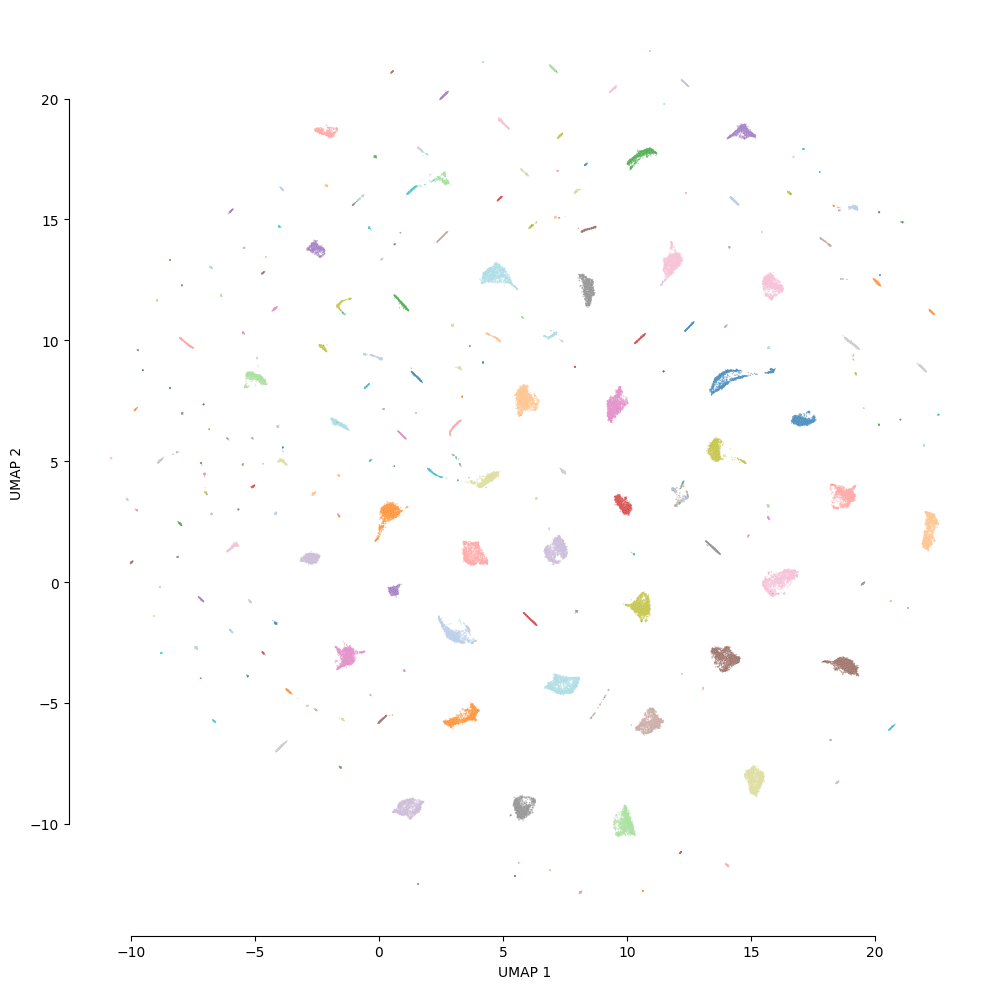

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    s=1,
    alpha=0.5,
    hue=cl.vect_labels_,  # color by (cell type) labels
    palette='tab20',
    ax=ax,
)

# Avoid having a giant legend with all the different cell types
ax.get_legend().remove()

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

sns.despine(trim=True)
plt.tight_layout()